<a href="https://colab.research.google.com/github/johnisaiah09/FinanceResearch-TCS-/blob/main/Stock_Market_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Imports and loading dataset
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from google.colab import userdata
import requests
import time


API_KEY = userdata.get("ALPHA_VANTAGE_API_KEY")
data_raw = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")
data = data_raw.copy()

Shape: (6290, 8)
Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Ticker'],
      dtype='object')
Data types: Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
Ticker        object
dtype: object
Date range: 2019-01-02 to 2023-12-29
Companies: ['AAPL' 'MSFT' 'AMZN' 'GOOGL' 'TSLA']
Rows per company: Ticker
AAPL     1258
MSFT     1258
AMZN     1258
GOOGL    1258
TSLA     1258
Name: count, dtype: int64
Number of invalid rows: 0


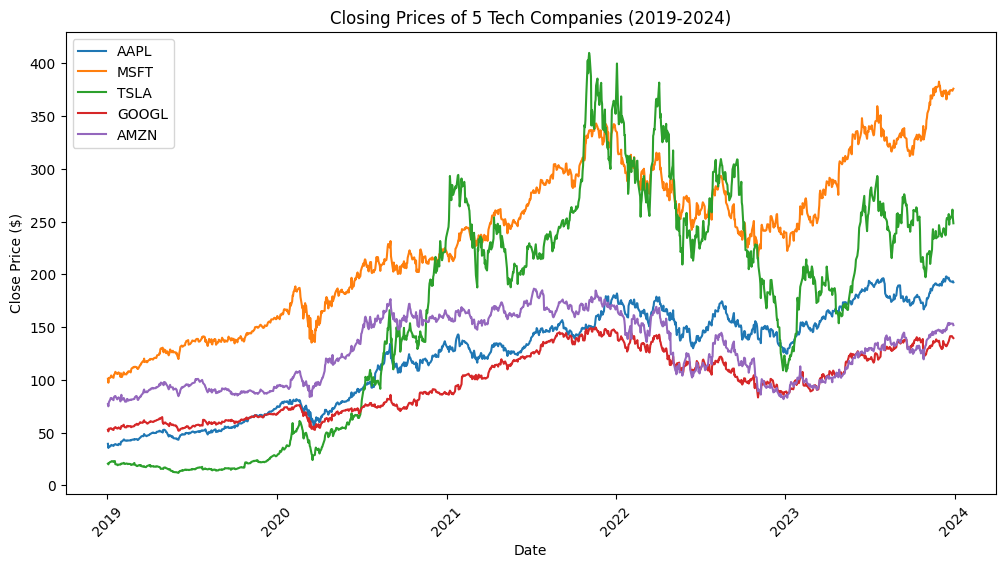

In [ ]:
#EDA
print("Shape:", data.shape)
print("Columns:", data.columns)
print("Data types:", data.dtypes)
print("Date range:", data["Date"].min(), "to", data["Date"].max())
print("Companies:", data["Ticker"].unique())
print("Rows per company:", data["Ticker"].value_counts())

# Converting the Date column to datetime
data["Date"] = pd.to_datetime(data["Date"])

#Dropping Adj. Close
data = data.drop(columns=["Adj Close"])

# Checking data is sorted
data = data.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)
data.head(10)

# Checking for invalid OHLC rows

invalid_rows = data[
    (data["High"] < data["Open"]) |
    (data["High"] < data["Close"]) |
    (data["High"] < data["Low"]) |
    (data["Low"] > data["Open"]) |
    (data["Low"] > data["Close"])
]

print(f"Number of invalid rows: {len(invalid_rows)}")

# Understanding numerical data
data.describe()

# Summary stats by Company
summary = data.groupby("Ticker").agg(
    {
        "Close": ["mean","std","min","max"],
        "Volume": ["mean","std","min","max"]
    }
)
summary

# Closing Price Visualization
companies = ["AAPL", "MSFT", "TSLA", "GOOGL", "AMZN"]

plt.figure(figsize=(12,6))
for company in companies:
  stock = data[data["Ticker"] == company]
  plt.plot(stock["Date"], stock["Close"], label=company)

plt.title("Closing Prices of 5 Tech Companies (2019-2024)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.xticks(rotation=45)
plt.show()




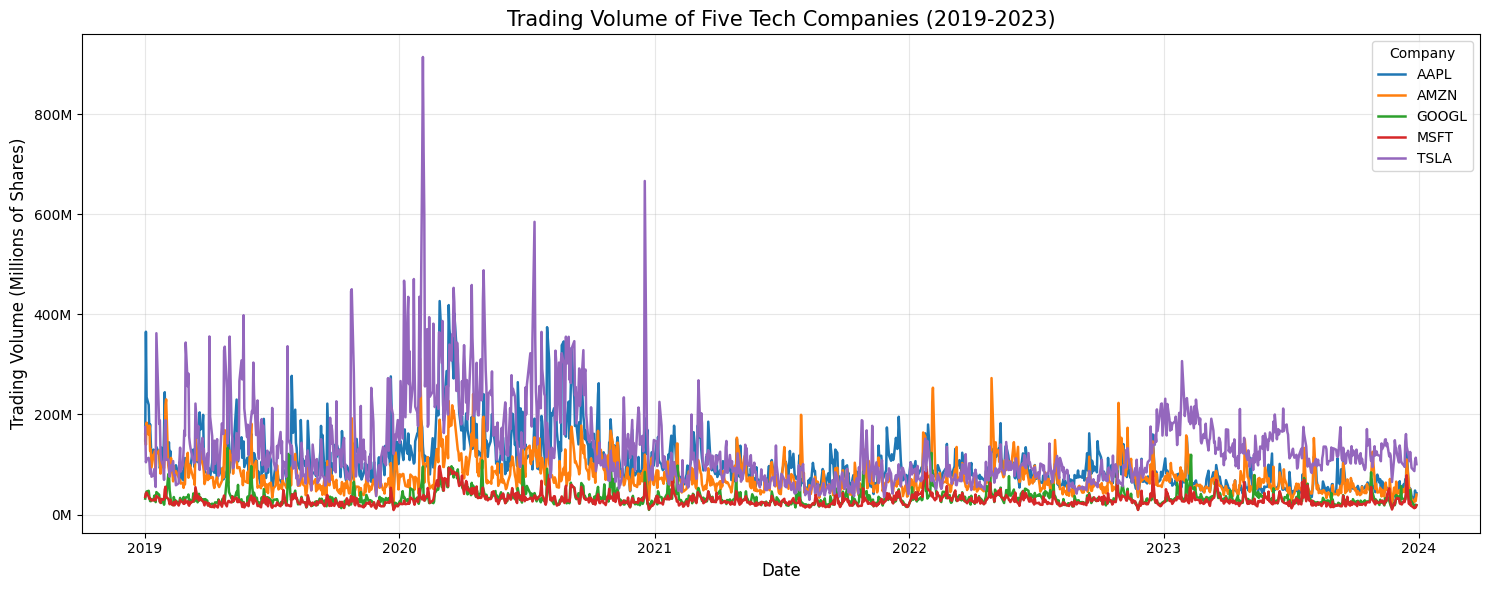

In [ ]:
# Trading Volume Visualization
plt.figure(figsize=(15,6))

for ticker in data["Ticker"].unique():
  company = data[data["Ticker"] == ticker]
  plt.plot(
      company["Date"],
      company["Volume"],
      linewidth=1.8,
      label = ticker
  )

plt.title("Trading Volume of Five Tech Companies (2019-2023)", fontsize=15)
plt.xlabel("Date",fontsize=12)
plt.ylabel("Trading Volume (Millions of Shares)", fontsize=12)
plt.grid(True, alpha=0.3)
#Format y-axis in millions instead of sci-notation
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x,pos: f"{x/1e6:.0f}M")
)

plt.legend(title="Company")
plt.tight_layout()
plt.show()

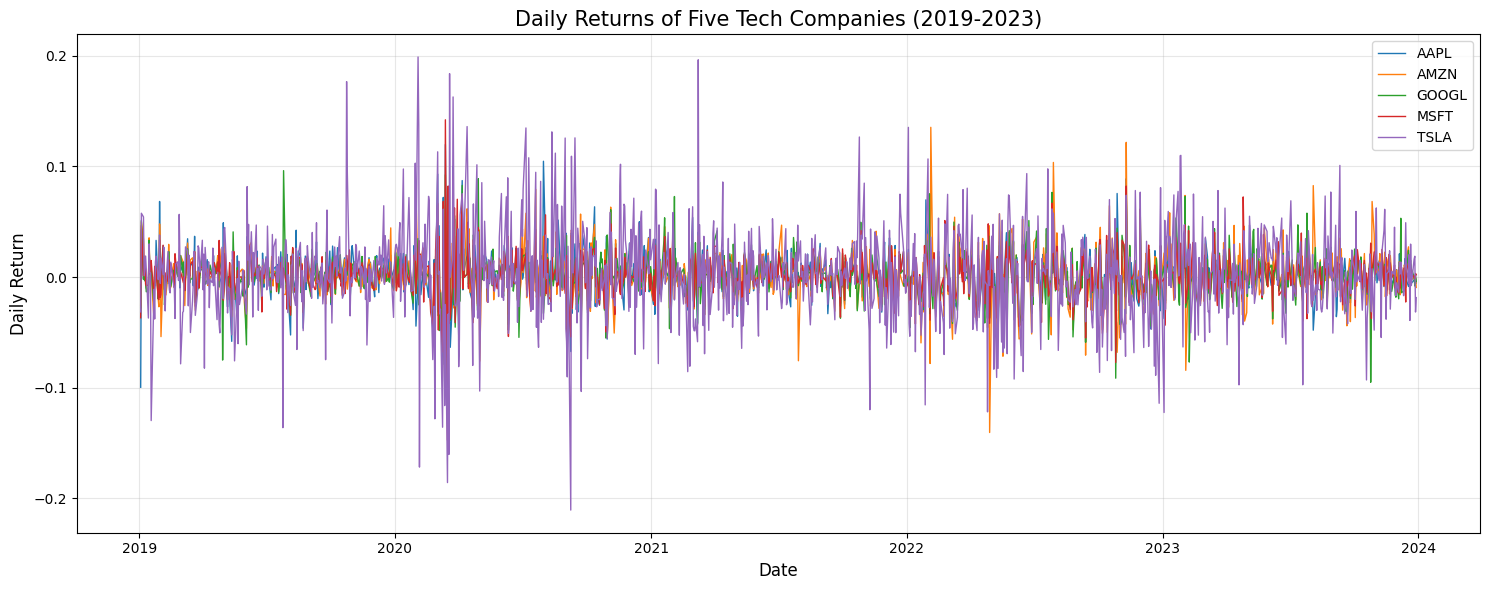

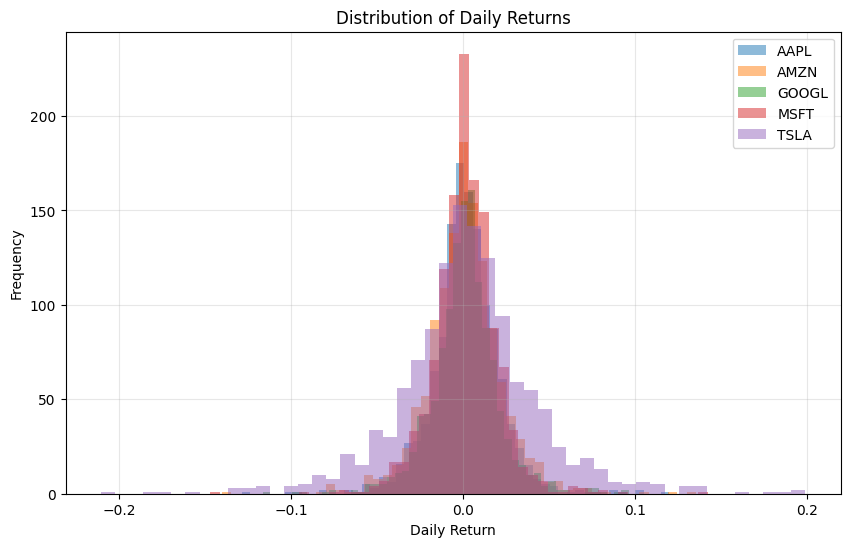

In [ ]:
from PIL.Image import linear_gradient
#Daily Returns for each company
data["Daily Return"] = (data.groupby("Ticker")["Close"].pct_change())

plt.figure(figsize=(15,6))

for ticker in data["Ticker"].unique():
  company = data[data["Ticker"] == ticker]

  plt.plot(
      company["Date"],
      company["Daily Return"],
      label=ticker,
      linewidth=1
  )

plt.title("Daily Returns of Five Tech Companies (2019-2023)", fontsize=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Return", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))

for ticker in data["Ticker"].unique():
  company = data[data["Ticker"] == ticker]

  plt.hist(
      company["Daily Return"],
      bins=50,
      alpha=0.5,
      label=ticker
  )

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

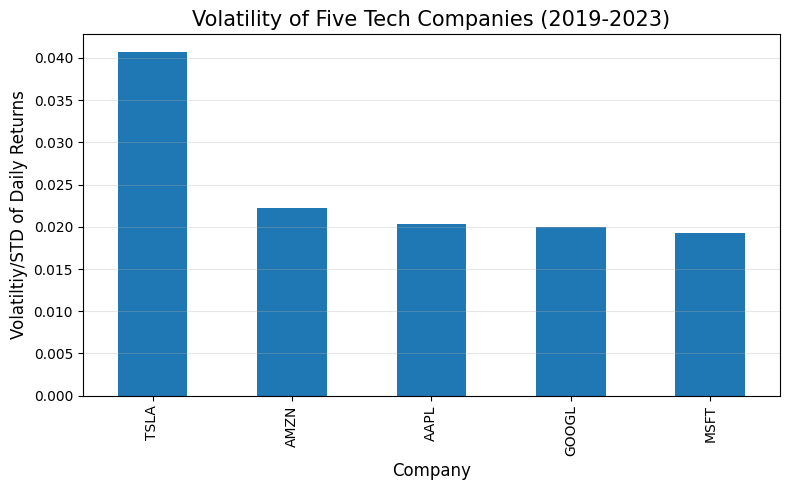

In [ ]:
#Volatility
volatility = data.groupby("Ticker")["Daily Return"].std().sort_values(ascending=False)

plt.figure(figsize=(8,5))

volatility.plot(kind="bar")

plt.title("Volatility of Five Tech Companies (2019-2023)", fontsize=15)
plt.xlabel("Company", fontsize=12)
plt.ylabel("Volatiltiy/STD of Daily Returns", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

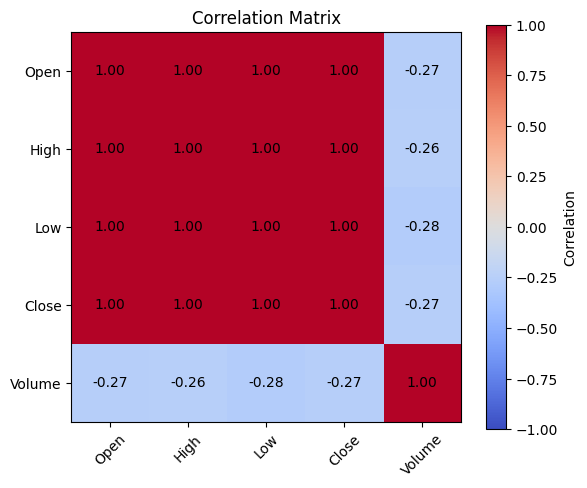

In [ ]:
#Correlation

corr = data[["Open", "High", "Low", "Close", "Volume"]].corr()
plt.figure(figsize=(6,5))

plt.imshow(corr,cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)

for i in range(len(corr.columns)):
  for j in range(len(corr.columns)):
    plt.text(
        j,
        i,
        f"{corr.iloc[i,j]:.2f}",
        ha="center",
        va="center",
        color="black"
    )
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



In [ ]:
#Data Preparation

#Get tomorrow's closing price for each company
data["Next_Close"] = data.groupby("Ticker")["Close"].shift(-1)

#Removing last trading day for each company
data = data.dropna(subset=["Next_Close"]).copy()

#Creating target
data["Target"] = (data["Next_Close"] > data["Close"]).astype(int)

#Getting rid of Next_Close
data.drop(columns=["Next_Close"], inplace=True)

#Checks (used once)
#print(data[["Date", "Ticker", "Close", "Target"]].head(10))
#print(data["Target"].value_counts())

In [ ]:
#Train/Test Split

#Training data: 2019-2022
train_data = data[data["Date"] < "2023-01-01"].copy()

#Testing data: 2023
test_data = data[data["Date"] >= "2023-01-01"].copy()

#Check 1
#print("Training period:")
#print(train_data["Date"].min(), "to", train_data["Date"].max())
#print()
#print("Testing period:")
#print(test_data["Date"].min(), "to", test_data["Date"].max())#

#Check2
#print("Training rows:", len(train_data))
#print("Testing rows:", len(test_data))

#Check3
#print(train_data["Ticker"].value_counts())
#print()
#print(test_data["Ticker"].value_counts())



In [ ]:
#Feature Scaling
features = ["Open","High","Low","Close","Volume"]
scaler = MinMaxScaler()
train_data[features] = scaler.fit_transform(train_data[features])
test_data[features] = scaler.transform(test_data[features])

#Checks
#print(train_data[features].describe())
#print(train_data[features].head())


In [ ]:
#Creating 15-Day Sequence
LOOKBACK = 15

features = ["Open","High", "Low", "Close", "Volume"]

#Function to create sequenes for one company
def create_sequences(data, features, target, lookback):

  X=[]
  y=[]

  for i in range(lookback, len(data)):

    #previous 30 trading days
    X.append(data[features].iloc[i-lookback:i].values)

    #Target for the current day
    y.append(data[target].iloc[i])

  return np.array(X), np.array(y)

#Empty list to store sequences
X_train_list = []
y_train_list = []

X_test_list = []
y_test_list = []

#Build sequences separately for each company
for ticker in train_data["Ticker"].unique():

  #Training data
  company_train = (
      train_data[train_data["Ticker"]==ticker].sort_values("Date").reset_index(drop=True)
  )
  X, y = create_sequences(company_train, features, "Target", LOOKBACK)
  X_train_list.append(X)
  y_train_list.append(y)

  #Testing data
  company_test = (
      test_data[test_data["Ticker"]==ticker].sort_values("Date").reset_index(drop=True)
  )
  X, y = create_sequences(company_test, features, "Target", LOOKBACK)
  X_test_list.append(X)
  y_test_list.append(y)

  #Combining companies into one dataset
  X_train = np.concatenate(X_train_list)
  y_train = np.concatenate(y_train_list)

  X_test = np.concatenate(X_test_list)
  y_test = np.concatenate(y_test_list)

  #Checks
#print("X_train shape:", X_train.shape)
#print("y_train shape:", y_train.shape)
#print("X_test shape:", X_test.shape)
#print("y_test shape:", y_test.shape)

#print("Example sequence shape:", X_train[0].shape)
#print("First target:", y_train[0])

In [ ]:
#Bulding model
model = Sequential([
    Input(shape=(LOOKBACK, len(features))),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1,activation="sigmoid")

])

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#Display
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training Baseline LSTM model

#Class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced",classes = classes, y=y_train)

class_weights = {0:weights[0], 1:weights[1]}
print(class_weights)



 #Early Stopping
early_stop = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop],
    class_weight=class_weights,
    shuffle=False
)

{0: np.float64(1.0590870307167235), 1: np.float64(0.9471575734452499)}
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4862 - loss: 0.6947 - val_accuracy: 0.4965 - val_loss: 0.6942
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4804 - loss: 0.6936 - val_accuracy: 0.5065 - val_loss: 0.6938
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4899 - loss: 0.6930 - val_accuracy: 0.5045 - val_loss: 0.6929
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4990 - loss: 0.6933 - val_accuracy: 0.5055 - val_loss: 0.6930
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5093 - loss: 0.6929 - val_accuracy: 0.5065 - val_loss: 0.6927
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5043 - loss: 0.6929 - val_accuracy: 0.5015 - val_loss: 0.6930
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5023 - loss: 0.6929 - val_accuracy: 0.5055 - val_loss: 0.6931
Epoch 8/50
125/125 ━━━━━━━━━

Test Loss: 0.6938
Test Accuracy: 0.5171
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
First 10 Predictions:
[1 1 1 1 1 1 1 1 1 1]

First 10 Actual Values:
[1 1 0 1 1 1 1 0 1 0]
Confusion Matrix:
[[249 285]
 [280 356]]

Classifaction Report:
              precision    recall  f1-score   support

           0       0.47      0.47      0.47       534
           1       0.56      0.56      0.56       636

    accuracy                           0.52      1170
   macro avg       0.51      0.51      0.51      1170
weighted avg       0.52      0.52      0.52      1170



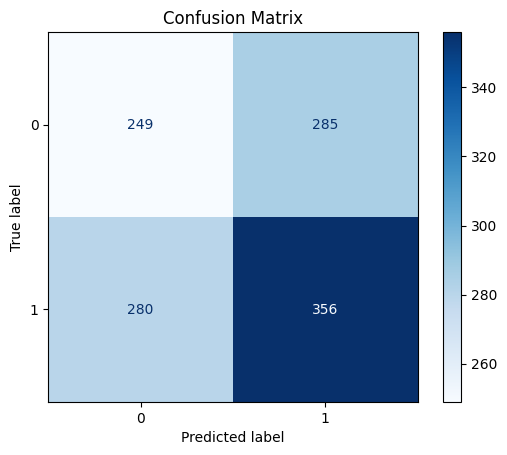

In [ ]:
#Evaluating on Test Set and getting predictions

#Eval on Test Set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

#Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)
y_pred = y_pred.flatten()

print("First 10 Predictions:")
print(y_pred[:10])
print()
print("First 10 Actual Values:")
print(y_test[:10])

#Classifications/Confusion Matrix

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nClassifaction Report:")
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Testing with Alpha Vantage API
#url = "https://www.alphavantage.co/query"
#params = {"function": "NEWS_SENTIMENT", "tickers": "AAPL", "apikey": API_KEY, "time_from": "20190101T0000", "time_to": "20241231T2359", "limit": 1000, "sort": "EARLIEST"}
#response = requests.get(url, params=params)
#news_data = response.json()
#print(news_data.keys())

#Seeing what is given with feed
#article = news_data["feed"][0]
#article.keys()

In [ ]:
#Creating reusable function
def get_news_for_year(ticker,year,api_key):
  url = "https://www.alphavantage.co/query"
  params = {"function": "NEWS_SENTIMENT", "tickers": ticker, "time_from": f"{year}0101T0000", "time_to": f"{year}1231T2359", "sort": "EARLIEST", "limit":1000, "apikey": api_key}
  response = requests.get(url, params=params)
  news_data = response.json()

  #Prevent crashes
  if "feed" not in news_data:
    print("API Error:")
    print(news_data)
    return pd.DataFrame()


  articles = []

  for article in news_data["feed"]:
    articles.append({
        "Date": pd.to_datetime(article["time_published"][:8], format="%Y%m%d"),
        "Ticker": ticker,
        "Title": article["title"],
        "Sentiment Score": article["overall_sentiment_score"],
        "Summary": article["summary"],
        "SentimentLabel": article["overall_sentiment_label"],
        "Source": article["source"],
        "Year": year
    })

  time.sleep(12)
  return pd.DataFrame(articles)


In [ ]:
#Collecting AAPL News Data

years = [2019, 2020, 2021, 2022, 2023]

apple_news = []

for year in years:
  print(f"Collecting AAPL {year}...")

  yearly_news = get_news_for_year("AAPL",year,API_KEY)

  apple_news.append(yearly_news)

apple_news_df = pd.concat(apple_news,ignore_index=True)



#Preserve the raw news dataset
news_raw = apple_news_df.copy()

#Checks

print("Dataset Shape:", apple_news_df.shape)

print("Date Range:", apple_news_df["Date"].min(), "to", apple_news_df["Date"].max())

apple_news_df.head()

Dataset Shape: (3102, 8)
Date Range: 2019-01-01 00:00:00 to 2023-12-30 00:00:00


,Date,Ticker,Title,Sentiment Score,Summary,SentimentLabel,Source,Year
0,2019-01-01,AAPL,Globalfoundries Launches Legal Battle Against ...,-0.089855,Globalfoundries has initiated a multi-front le...,Neutral,The Wall Street Journal,2019
1,2019-01-02,AAPL,Netflix Just Made a Truly Radical Change Affec...,0.109977,Netflix has implemented a significant change b...,Neutral,Inc.com,2019
2,2019-01-03,AAPL,"GaN market growing at CAGR of 55% to 2023, dri...",0.351147,The market for Gallium Nitride (GaN) is projec...,Bullish,Semiconductor Today,2019
3,2019-01-04,AAPL,Is Apple Still a ‘forever’ Company? How About ...,-0.107005,"This article questions the ""forever company"" t...",Neutral,American Enterprise Institute - AEI,2019
4,2019-01-06,AAPL,MD Anderson Cancer Center and Ascentage Pharma...,0.370641,MD Anderson Cancer Center and Ascentage Pharma...,Bullish,MD Anderson Cancer Center,2019


In [ ]:
#Save Apple news dataset to Google Colab

apple_news_df.to_csv("AAPL_news_2019_2023.csv", index=False)
print("Saved as AAPL_news_2019_2023.csv")

from google.colab import files
files.download("AAPL_news_2019_2023.csv")

Saved as AAPL_news_2019_2023.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
#Loading Apple CSV
apple_news_df = pd.read_csv("AAPL_news_2019_2023.csv", parse_dates=["Date"])
apple_news_df["Date"] = pd.to_datetime(apple_news_df["Date"])
print(apple_news_df.shape)
apple_news_df.head()

(3102, 8)


,Date,Ticker,Title,Sentiment Score,Summary,SentimentLabel,Source,Year
0,2019-01-01,AAPL,Globalfoundries Launches Legal Battle Against ...,-0.089855,Globalfoundries has initiated a multi-front le...,Neutral,The Wall Street Journal,2019
1,2019-01-02,AAPL,Netflix Just Made a Truly Radical Change Affec...,0.109977,Netflix has implemented a significant change b...,Neutral,Inc.com,2019
2,2019-01-03,AAPL,"GaN market growing at CAGR of 55% to 2023, dri...",0.351147,The market for Gallium Nitride (GaN) is projec...,Bullish,Semiconductor Today,2019
3,2019-01-04,AAPL,Is Apple Still a ‘forever’ Company? How About ...,-0.107005,"This article questions the ""forever company"" t...",Neutral,American Enterprise Institute - AEI,2019
4,2019-01-06,AAPL,MD Anderson Cancer Center and Ascentage Pharma...,0.370641,MD Anderson Cancer Center and Ascentage Pharma...,Bullish,MD Anderson Cancer Center,2019


In [7]:
#Categorizing Apple Financial News
def categorize_news(row):
  text = (str(row["Title"]) + "" + str(row["Summary"])).lower()

  #Earnings / Financial Results
  if any(word in text for word in ["earnings","revenue","profit","quarter", "financial results", "eps", "income", "sales","quarter results", "quarterly results", "eps"]):
    return "Earnings"

  #Legal / Regulatory
  elif any(word in text for word in["lawsuit","court", "regulation","government","antitrust","fine","investigation","legal"]):
    return "Legal/Regulatory"

  #Mergers & Acquisitions
  elif any(word in text for word in ["acquisition","acquire","merger","buyout","deal","partnership"]):
    return "M&A"

  #Analyst Ratings
  elif any(word in text for word in ["analyst", "upgrade", "downgrade", "price target", "rating", "wall street"]):
    return "Analyst Ratings"

  #Management / Corporate
  elif any(word in text for word in ["ceo", "executive", "leadership", "board", "resign", "appointment"]):
    return "Management/Corporate"

  #Product / Technology
  elif any(word in text for word in["iphone", "ipad", "mac", "apple watch", "launch", "release", "product", "technology","software", "ai"]):
    return "Product/Technology"

  #Macro / Market
  elif any(word in text for word in ["inflation","interest rate","fed","economy","market","recession"]):
    return "Macro"

  else:
    return "Other"

#Apply categories
apple_news_df["Category"] = apple_news_df.apply(categorize_news, axis=1)

#Check category distribution
print(apple_news_df["Category"].value_counts())

#View examples
apple_news_df[["Title","Category"]].head(20)

Category
Product/Technology      1144
Earnings                 682
M&A                      318
Legal/Regulatory         298
Analyst Ratings          226
Management/Corporate     196
Other                    142
Macro                     96
Name: count, dtype: int64


,Title,Category
0,Globalfoundries Launches Legal Battle Against ...,Legal/Regulatory
1,Netflix Just Made a Truly Radical Change Affec...,Earnings
2,"GaN market growing at CAGR of 55% to 2023, dri...",Legal/Regulatory
3,Is Apple Still a ‘forever’ Company? How About ...,Product/Technology
4,MD Anderson Cancer Center and Ascentage Pharma...,Product/Technology
5,Philips Cares digitizes the aging and caregivi...,Product/Technology
6,Vuzix announces the launch of consumer version...,Product/Technology
7,Apple struggled in China. Abbott Labs isn't,Earnings
8,"Apple considered Samsung, MediaTek to supply 5...",Management/Corporate
9,UnitedHealth Group to Launch Electronic Health...,Product/Technology


In [8]:
#Save categorized Apple news dataset
apple_news_df.to_csv("AAPL_categorized_news_2019_2023.csv",index=False)
print("Saved Categorized apple news dataset as AAPL_categorized_news_2019_2023.csv")


Saved Categorized apple news dataset as AAPL_categorized_news_2019_2023.csv


In [9]:
#Converting article news into daily features

#Make sure it is in datetime
apple_news_df["Date"] = pd.to_datetime(apple_news_df["Date"])

#Create article count by category per day
category_counts = (apple_news_df.groupby(["Date","Category"]).size().unstack(fill_value=0))

#Rename columns
category_counts.columns = [f"{col}_Count" for col in category_counts.columns]

#create avg. sentiment by category per day
category_sentiment = (apple_news_df.groupby(["Date", "Category"])["Sentiment Score"].mean().unstack(fill_value=0))

#Rename Columns
category_sentiment.columns = [f"{col}_Sentiment" for col in category_sentiment.columns]

#Combining count and sentiment features
daily_news_features = pd.concat([category_counts, category_sentiment], axis=1).reset_index()

#Add total features
daily_news_features["Total_News_Count"] = (apple_news_df.groupby("Date").size().values)
daily_news_features["Average_News_Sentiment"] = (apple_news_df.groupby("Date")["Sentiment Score"].mean().values)

#Display Result
print("Shape:", daily_news_features.shape)
print(daily_news_features.columns)
daily_news_features.head()


Shape: (1188, 19)
Index(['Date', 'Analyst Ratings_Count', 'Earnings_Count',
       'Legal/Regulatory_Count', 'M&A_Count', 'Macro_Count',
       'Management/Corporate_Count', 'Other_Count', 'Product/Technology_Count',
       'Analyst Ratings_Sentiment', 'Earnings_Sentiment',
       'Legal/Regulatory_Sentiment', 'M&A_Sentiment', 'Macro_Sentiment',
       'Management/Corporate_Sentiment', 'Other_Sentiment',
       'Product/Technology_Sentiment', 'Total_News_Count',
       'Average_News_Sentiment'],
      dtype='object')


,Date,Analyst Ratings_Count,Earnings_Count,Legal/Regulatory_Count,M&A_Count,Macro_Count,Management/Corporate_Count,Other_Count,Product/Technology_Count,Analyst Ratings_Sentiment,Earnings_Sentiment,Legal/Regulatory_Sentiment,M&A_Sentiment,Macro_Sentiment,Management/Corporate_Sentiment,Other_Sentiment,Product/Technology_Sentiment,Total_News_Count,Average_News_Sentiment
0,2019-01-01,0,0,1,0,0,0,0,0,0.0,0.000000,-0.089855,0.0,0.0,0.0,0.0,0.000000,1,-0.089855
1,2019-01-02,0,1,0,0,0,0,0,0,0.0,0.109977,0.000000,0.0,0.0,0.0,0.0,0.000000,1,0.109977
2,2019-01-03,0,0,1,0,0,0,0,0,0.0,0.000000,0.351147,0.0,0.0,0.0,0.0,0.000000,1,0.351147
3,2019-01-04,0,0,0,0,0,0,0,1,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,-0.107005,1,-0.107005
4,2019-01-06,0,0,0,0,0,0,0,1,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.370641,1,0.370641


In [2]:
#Creating Apple-only Stock Dateset
apple_stock_df = data[data["Ticker"] == "AAPL"].copy()

print("Shape:", apple_stock_df.shape)
print("Date Ramge:", apple_stock_df["Date"].min(),"to",apple_stock_df["Date"].max())
apple_stock_df.head()

Shape: (1258, 8)
Date Ramge: 2019-01-02 to 2023-12-29


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL


In [11]:
#Fix Date Formats Before Merge
apple_stock_df["Date"] = pd.to_datetime(apple_stock_df["Date"])
daily_news_features["Date"] = pd.to_datetime(daily_news_features["Date"])

print(apple_stock_df["Date"].dtype)
print(daily_news_features["Date"].dtype)

#Merging Apple Stock with Daily News Features
hybrid_data = apple_stock_df.merge(daily_news_features,on="Date",how="left")

#Trading days with no news get zeros
hybrid_data = hybrid_data.fillna(0)

#Check
print("Shape:", hybrid_data.shape)

print("\nMissing values:")
print(hybrid_data.isnull().sum().sum())

hybrid_data.head()

datetime64[ns]
datetime64[ns]
Shape: (1258, 26)

Missing values:
0


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Analyst Ratings_Count,Earnings_Count,...,Analyst Ratings_Sentiment,Earnings_Sentiment,Legal/Regulatory_Sentiment,M&A_Sentiment,Macro_Sentiment,Management/Corporate_Sentiment,Other_Sentiment,Product/Technology_Sentiment,Total_News_Count,Average_News_Sentiment
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL,0.0,1.0,...,0.0,0.109977,0.000000,0.0,0.0,0.0,0.0,0.000000,1.0,0.109977
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL,0.0,0.0,...,0.0,0.000000,0.351147,0.0,0.0,0.0,0.0,0.000000,1.0,0.351147
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,-0.107005,1.0,-0.107005
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.331884,1.0,0.331884
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL,0.0,1.0,...,0.0,-0.071779,0.000000,0.0,0.0,0.0,0.0,0.283720,2.0,0.105971


In [20]:
#Hybrid Model Data prep: OHLCV + AAPL News Features

# Make sure Date is datetime
hybrid_data["Date"] = pd.to_datetime(hybrid_data["Date"])

# Sort by date
hybrid_data = hybrid_data.sort_values("Date").reset_index(drop=True) #

#Get tomorrow's closing price
hybrid_data["Next_Close"] = hybrid_data["Close"].shift(-1)

# Remove final row (no next day available)
hybrid_data = hybrid_data.dropna(subset=["Next_Close"]).copy()

# Create binary target # 1 = tomorrow close is higher # 0 = tomorrow close is lower
hybrid_data["Target"] = ( hybrid_data["Next_Close"] > hybrid_data["Close"] ).astype(int)

# Remove Next_Close
hybrid_data.drop(columns=["Next_Close"], inplace=True)

print("Shape after target creation:", hybrid_data.shape)

print(hybrid_data[["Date","Close","Target"]].head())



Shape after target creation: (1254, 27)
        Date      Close  Target
0 2019-01-02  39.480000       0
1 2019-01-03  35.547501       1
2 2019-01-04  37.064999       0
3 2019-01-07  36.982498       1
4 2019-01-08  37.687500       1


In [21]:
#Train/Test Split
train_hybrid = hybrid_data[ hybrid_data["Date"] < "2023-01-01" ].copy()

test_hybrid = hybrid_data[ hybrid_data["Date"] >= "2023-01-01" ].copy()
print("Training shape:", train_hybrid.shape)
print("Testing shape:", test_hybrid.shape)

print( "Training dates:", train_hybrid["Date"].min(), "to", train_hybrid["Date"].max() )

print( "Testing dates:", test_hybrid["Date"].min(), "to", test_hybrid["Date"].max() )


Training shape: (1008, 27)
Testing shape: (246, 27)
Training dates: 2019-01-02 00:00:00 to 2022-12-30 00:00:00
Testing dates: 2023-01-03 00:00:00 to 2023-12-22 00:00:00


In [22]:
#Feature scaling

features = [ "Open", "High", "Low", "Close", "Volume", "Analyst Ratings_Count", "Earnings_Count", "Legal/Regulatory_Count", "M&A_Count", "Macro_Count", "Management/Corporate_Count", "Other_Count", "Product/Technology_Count", "Analyst Ratings_Sentiment", "Earnings_Sentiment", "Legal/Regulatory_Sentiment", "M&A_Sentiment", "Macro_Sentiment", "Management/Corporate_Sentiment", "Other_Sentiment", "Product/Technology_Sentiment", "Total_News_Count", "Average_News_Sentiment" ]

scaler = MinMaxScaler()

train_hybrid[features] = scaler.fit_transform( train_hybrid[features] )
test_hybrid[features] = scaler.transform( test_hybrid[features] )

print("Scaling complete")
print(train_hybrid[features].describe())


Scaling complete
              Open         High          Low        Close       Volume  \
count  1008.000000  1008.000000  1008.000000  1008.000000  1008.000000   
mean      0.509229     0.516033     0.514227     0.513458     0.196527   
std       0.294900     0.298763     0.297064     0.295114     0.135721   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.208716     0.211321     0.211217     0.212670     0.108246   
50%       0.598152     0.605078     0.603502     0.601502     0.157782   
75%       0.757118     0.766757     0.766450     0.761270     0.239873   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

       Analyst Ratings_Count  Earnings_Count  Legal/Regulatory_Count  \
count            1008.000000     1008.000000             1008.000000   
mean                0.080357        0.100198                0.071759   
std                 0.195508        0.170518                0.162148   
min                 0.000000

In [25]:
#Creating 15-Day Sequences
LOOKBACK = 15

def create_sequences(data, features, target, lookback):
  X = []
  y = []

  for i in range(lookback, len(data)):
    X.append( data[features].iloc[i-lookback:i].values )
    y.append( data[target].iloc[i] )
  return np.array(X), np.array(y)

X_train, y_train = create_sequences( train_hybrid, features, "Target", LOOKBACK )

X_test, y_test = create_sequences( test_hybrid, features, "Target", LOOKBACK )

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (993, 15, 23)
y_train shape: (993,)
X_test shape: (231, 15, 23)
y_test shape: (231,)


In [ ]:
#Store company news datasets seperately
#news_datasets = {}

#Save AAPL dataset
#news_datasets["AAPL"] = apple_news_df

#Remaining Companies to collect
#remaining_tickers = ["MSFT", "TSLA", "GOOGL", "AMZN"]

#years = [2019,2020,2021,2022,2023]


#for ticker in remaining_tickers:
#print(f"\nStarting collection for {ticker}")

#  company_news = []

#for year in years:
 #   print(f"Collecting {ticker} {year}...")

  #  yearly_news = get_news_for_year(ticker,year,API_KEY)

  #  company_news.append(yearly_news)

  #company_df = pd.concat(company_news, ignore_index=True)

#  news_datasets[ticker] = company_df

#  print(f"{ticker} complete!")
#  print("Shape:", company_df.shape)

